In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6e}")

PROJECT_ROOT = Path("..")

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "modis_merra2_aligned.csv"
FEATURE_FILE = PROJECT_ROOT / "data" / "processed" / "proxy_bc_features.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

df = pd.read_csv(DATA_FILE)
model_df = pd.read_csv(FEATURE_FILE)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
model_df["datetime"] = pd.to_datetime(model_df["datetime"], errors="coerce")

print("Original aligned dataset:", df.shape)
print("Model feature dataset:", model_df.shape)

Original aligned dataset: (146, 35)
Model feature dataset: (146, 14)


In [2]:
print("Dataset date range:")
print(df["datetime"].min(), "to", df["datetime"].max())

print("\nModel features:")
print(model_df.columns.tolist())

Dataset date range:
2025-09-09 10:00:00 to 2025-12-25 05:10:00

Model features:
['datetime', 'BCCMASS', 'aod_047', 'aod_055', 'T2M', 'PS', 'PBLTOP', 'U10M', 'V10M', 'QV2M', 'WIND_SPEED', 'TOTEXTTAU', 'month', 'hour']


In [3]:
overview = pd.DataFrame({
    "Metric": [
        "Number of observations",
        "Number of variables",
        "Start date",
        "End date"
    ],
    "Value": [
        len(model_df),
        len(model_df.columns),
        model_df["datetime"].min(),
        model_df["datetime"].max()
    ]
})

overview

,Metric,Value
0,Number of observations,146
1,Number of variables,14
2,Start date,2025-09-09 10:00:00
3,End date,2025-12-25 05:10:00


In [4]:
print("Model dataset columns:")
for i, col in enumerate(model_df.columns, start=1):
    print(f"{i}. {col}")

Model dataset columns:
1. datetime
2. BCCMASS
3. aod_047
4. aod_055
5. T2M
6. PS
7. PBLTOP
8. U10M
9. V10M
10. QV2M
11. WIND_SPEED
12. TOTEXTTAU
13. month
14. hour


In [5]:
missing_values = model_df.isna().sum().sort_values(ascending=False)

missing_values

datetime      0
BCCMASS       0
aod_047       0
aod_055       0
T2M           0
PS            0
PBLTOP        0
U10M          0
V10M          0
QV2M          0
WIND_SPEED    0
TOTEXTTAU     0
month         0
hour          0
dtype: int64

In [6]:
numeric_df = model_df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix["BCCMASS"].sort_values(ascending=False)

BCCMASS       1.000000e+00
TOTEXTTAU     8.038308e-01
aod_047       5.592813e-01
aod_055       5.570792e-01
PS            4.986630e-01
month         4.950130e-01
PBLTOP        1.979607e-01
hour          1.906009e-01
V10M         -1.730223e-01
WIND_SPEED   -1.949491e-01
U10M         -2.178086e-01
T2M          -3.520571e-01
QV2M         -5.138464e-01
Name: BCCMASS, dtype: float64

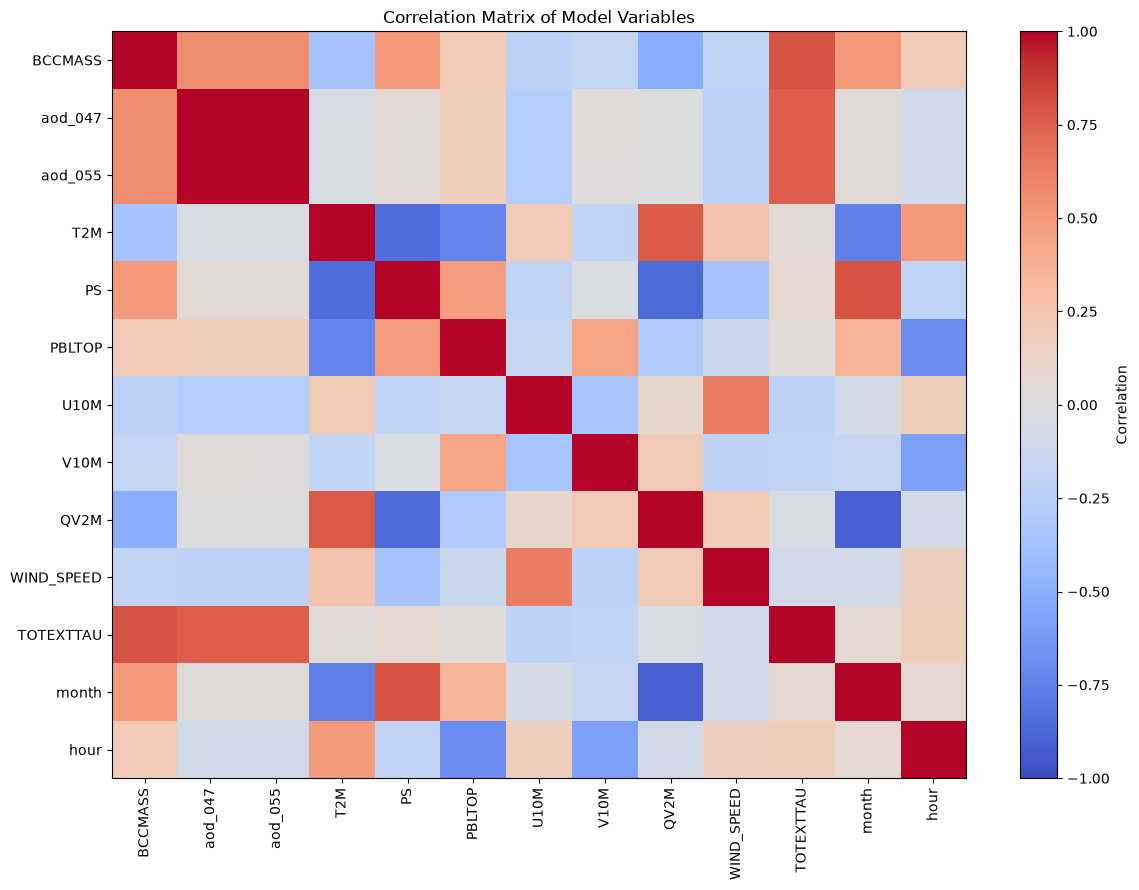

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Model Variables")
plt.tight_layout()
plt.show()

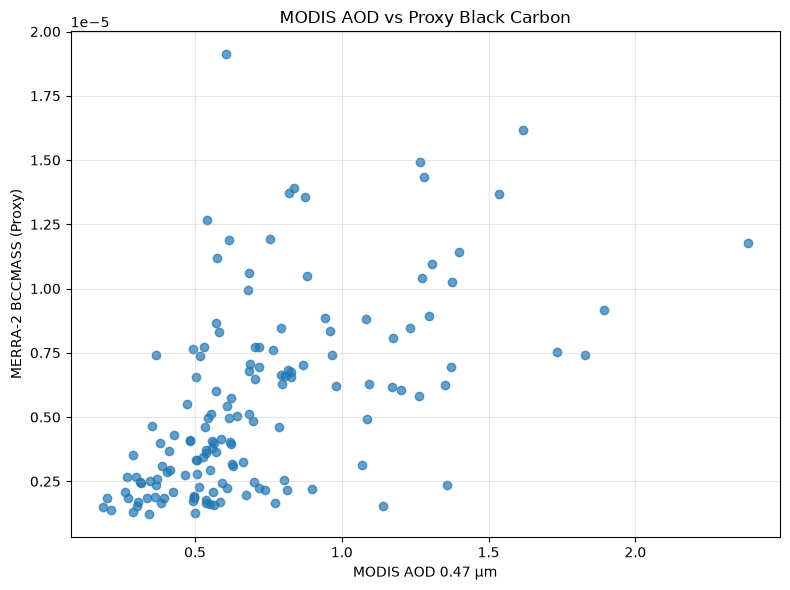

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    model_df["aod_047"],
    model_df["BCCMASS"],
    alpha=0.7
)

plt.xlabel("MODIS AOD 0.47 µm")
plt.ylabel("MERRA-2 BCCMASS (Proxy)")
plt.title("MODIS AOD vs Proxy Black Carbon")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

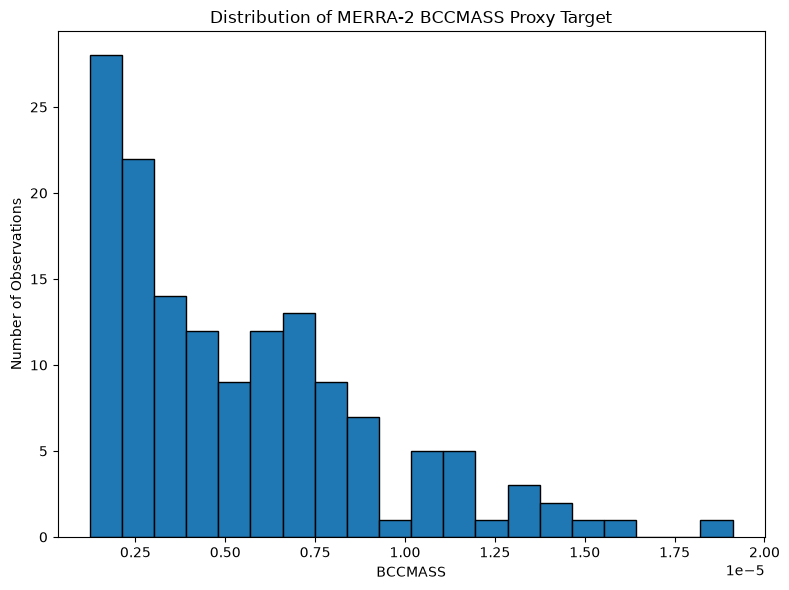

In [9]:
plt.figure(figsize=(8, 6))

plt.hist(
    model_df["BCCMASS"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("BCCMASS")
plt.ylabel("Number of Observations")
plt.title("Distribution of MERRA-2 BCCMASS Proxy Target")

plt.tight_layout()
plt.show()

In [10]:
model_results = pd.read_csv(
    OUTPUT_DIR / "model_comparison.csv"
)

model_results

,model,MAE,RMSE,R2
0,Linear Regression,1.290238e-06,1.606371e-06,8.123612e-01
1,Random Forest,1.254364e-06,1.661663e-06,7.992216e-01
2,Gradient Boosting,1.159431e-06,1.531340e-06,8.294804e-01


In [11]:
model_results_display = model_results.copy()

model_results_display["MAE"] = model_results_display["MAE"].map(
    lambda x: f"{x:.3e}"
)

model_results_display["RMSE"] = model_results_display["RMSE"].map(
    lambda x: f"{x:.3e}"
)

model_results_display["R2"] = model_results_display["R2"].map(
    lambda x: f"{x:.3f}"
)

model_results_display

,model,MAE,RMSE,R2
0,Linear Regression,1.290e-06,1.606e-06,0.812
1,Random Forest,1.254e-06,1.662e-06,0.799
2,Gradient Boosting,1.159e-06,1.531e-06,0.829


In [12]:
test_predictions = pd.read_csv(
    OUTPUT_DIR / "test_predictions.csv"
)

test_predictions.head()

,datetime,actual_BCCMASS,linear_regression_prediction,random_forest_prediction,gradient_boosting_prediction
0,2025-11-23 03:50:00,1.193233e-05,9.391969e-06,1.148148e-05,1.206094e-05
1,2025-11-23 09:10:00,1.120780e-05,9.505547e-06,1.091230e-05,1.076521e-05
2,2025-11-24 04:30:00,6.295660e-06,7.107613e-06,5.671274e-06,6.484411e-06
3,2025-11-24 09:45:00,8.448442e-06,8.073289e-06,7.226267e-06,7.454224e-06
4,2025-11-26 04:10:00,7.048389e-06,6.609981e-06,5.556184e-06,6.521036e-06


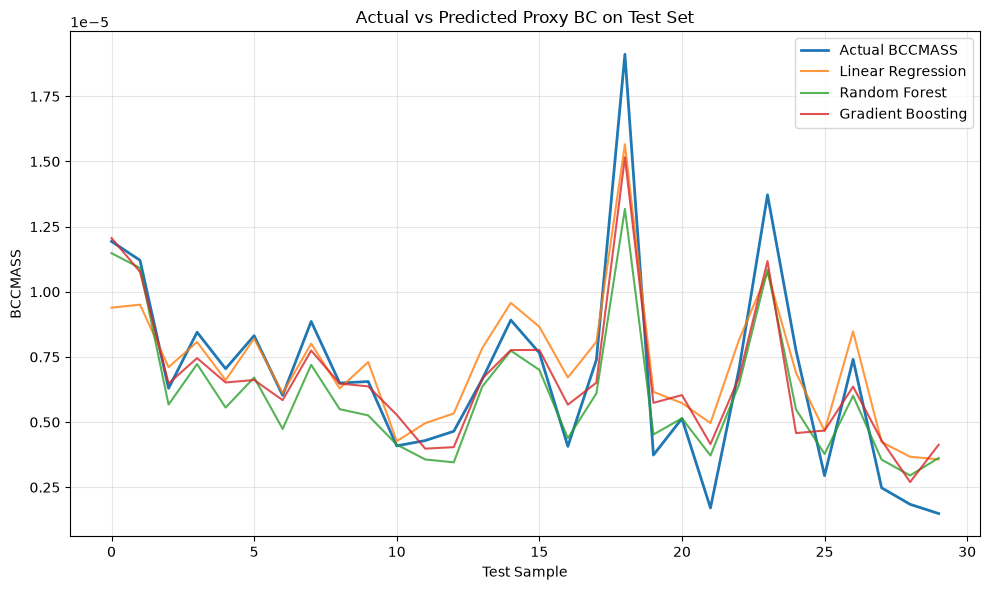

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    test_predictions["actual_BCCMASS"].values,
    label="Actual BCCMASS",
    linewidth=2
)

plt.plot(
    test_predictions["linear_regression_prediction"].values,
    label="Linear Regression",
    alpha=0.8
)

plt.plot(
    test_predictions["random_forest_prediction"].values,
    label="Random Forest",
    alpha=0.8
)

plt.plot(
    test_predictions["gradient_boosting_prediction"].values,
    label="Gradient Boosting",
    alpha=0.8
)

plt.xlabel("Test Sample")
plt.ylabel("BCCMASS")
plt.title("Actual vs Predicted Proxy BC on Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
gb_importance = pd.read_csv(
    OUTPUT_DIR / "gradient_boosting_feature_importance.csv"
)

gb_importance


,feature,importance
0,TOTEXTTAU,7.545009e-01
1,QV2M,1.477954e-01
2,PS,4.774491e-02
3,month,2.507022e-02
4,T2M,1.120885e-02
5,PBLTOP,5.294820e-03
6,aod_047,3.176529e-03
7,aod_055,1.767987e-03
8,V10M,1.442057e-03
9,WIND_SPEED,1.159939e-03


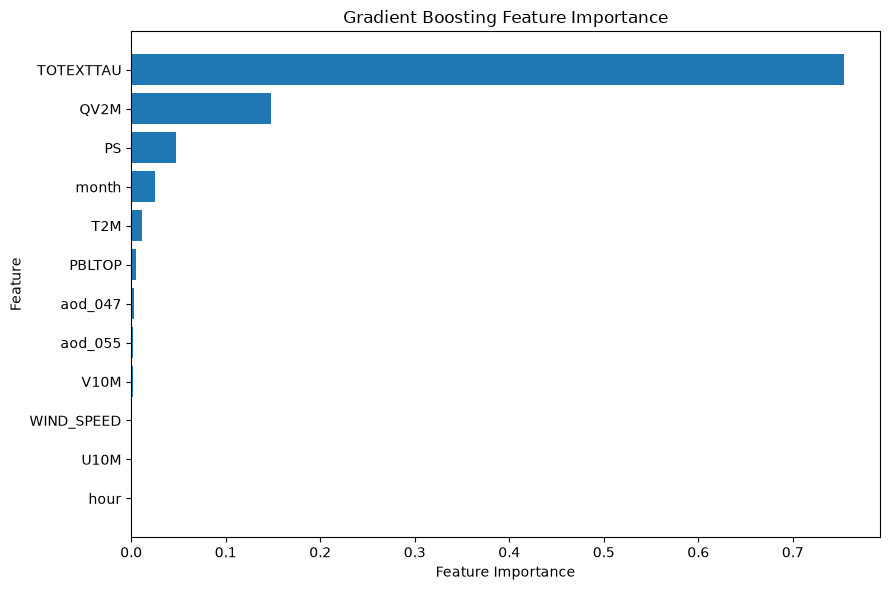

In [15]:
gb_importance = gb_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    gb_importance["feature"],
    gb_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

In [16]:
rf_importance = pd.read_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv"
)

rf_importance

,feature,importance
0,TOTEXTTAU,7.629980e-01
1,QV2M,1.321963e-01
2,PS,3.958974e-02
3,month,1.320121e-02
4,V10M,1.012710e-02
5,U10M,8.805175e-03
6,T2M,8.620877e-03
7,aod_055,6.729227e-03
8,aod_047,6.038548e-03
9,WIND_SPEED,5.435809e-03


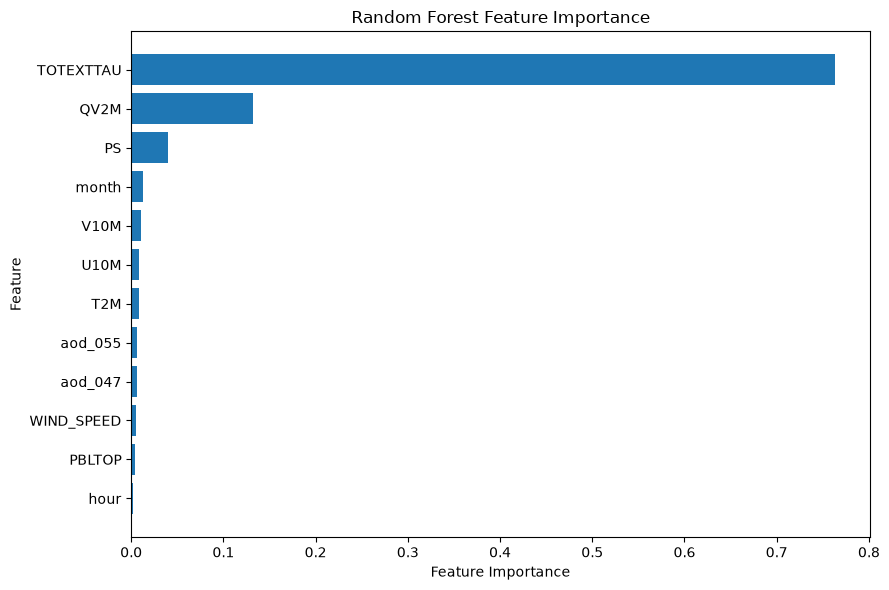

In [17]:
rf_importance = rf_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    rf_importance["feature"],
    rf_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## Preliminary Findings

The current dataset contains 146 matched MODIS and MERRA-2 observations with no missing values in the model features.

The correlation analysis shows a positive relationship between BCCMASS and total aerosol optical depth (TOTEXTTAU), while the two MODIS AOD features also show positive correlations with the proxy BC target.

For the preliminary modeling experiment, three models were evaluated using a chronological 80/20 train-test split. The R² values were 0.812 for Linear Regression, 0.799 for Random Forest, and 0.829 for Gradient Boosting. On this test split, Gradient Boosting produced an R² of 0.829, RMSE of 1.531e-06, and MAE of 1.159e-06.

The tree-based models also assigned relatively high feature importance to TOTEXTTAU and QV2M. These results show that the available satellite and meteorological variables contain useful information for modeling the current proxy target.

These results are preliminary and should not be interpreted as the final performance of the ground-level BC retrieval model.

## Current Limitations

The main limitation of the current experiment is the absence of ground-based Aethalometer BC concentration data.

BCCMASS from MERRA-2 is being used only as a temporary proxy target for testing the complete machine learning workflow. It is a reanalysis product and should not be treated as ground-truth ground-level BC measurements.

The current dataset also contains only 146 MODIS observations, which is relatively small for developing and validating a robust machine learning model.

TROPOMI data has also been processed separately, but the currently available TROPOMI observations do not overlap in time with the current MODIS-MERRA-2 dataset. Therefore, TROPOMI is not included in the present modeling experiment.

## Conclusion

This preliminary analysis establishes the main data processing and machine learning workflow for ground-level black carbon retrieval.

MODIS AOD observations were combined with MERRA-2 aerosol and meteorological variables to create a modeling dataset. Data quality checks showed no missing values in the current feature dataset, and initial correlation and machine learning analyses were performed.

The proxy experiment demonstrates that the available variables can be used to model the MERRA-2 BCCMASS proxy target. However, these results are not the final validation of ground-level BC retrieval.

The next major step is to obtain and integrate the Aethalometer measurements. These observations will provide the ground-based BC target required for developing and validating the final retrieval model.

## Next Step

Integrate the Aethalometer ground measurements, match them with the satellite and meteorological observations, retrain the models using measured BC concentration as the target, and perform final validation.